In [1]:
import os
import addons
import matplotlib.pyplot as plt
import numpy as np
import network_params
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.interpolate import pchip
from scipy.interpolate import make_smoothing_spline
from scipy.stats import entropy as scipy_entropy

/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
def compute_FFT(signal_data,freq_sample= 0.001):
    analysis_interval_start = (addons.analysis_dict["analysis_start"]) /0.2
    analysis_interval_end = (addons.analysis_dict["analysis_end"])/ 0.2
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    FFT_Results = {}

    for i in range(len(signal_data)):
        FFT_Results[i] = fft(signal_data[i][analysis_interval_start:analysis_interval_end]-np.mean(signal_data[i][analysis_interval_start:analysis_interval_end]))

    #Calcular los valores de frequencia correspondientes
    freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample)

    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    result_fourier = {}

    for i in FFT_Results:
        result_fourier[i] = np.abs(FFT_Results[i])[:indx]
    results_freq = freq[:indx]

    return result_fourier, results_freq, indx

In [3]:
def compute_spectral_entropy(result_fourier, results_freq, f_max=150.0):
    """
    Spectral entropy of the normalised power spectrum, restricted to [0, f_max] Hz.

    H = -sum(P * log(P))  where P is the normalised power (sums to 1) within
    [0, f_max] Hz.
    """
    mask = results_freq <= f_max
    spectral_entropy = {}
    for i in result_fourier:
        power      = result_fourier[i][mask] ** 2  
        total      = power.sum()
        if total == 0 or not np.isfinite(total):
            spectral_entropy[i] = np.nan
            continue
        power_norm = power / total      
        spectral_entropy[i] = scipy_entropy(power_norm, base=2)   # bits
    return spectral_entropy

In [4]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names       = [6, 9, 12, 18]
freq_sample = 0.0002

pops     = ["L23E", "L4E", "L5E", "L6E"]
n_pops   = len(pops)
n_drives = len(dirs)

all_entropy = {}
all_Q       = {}
all_bw      = {}

for i in range(n_drives):
    base = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    pop_activity_i = []
    for j in range(n_pops):
        fpath = base + "measurements/pop_activities/pop_activity_" + str(j * 2) + ".dat"
        pop_activity_i.append(np.loadtxt(fpath))
    pop_activity_i = np.array(pop_activity_i)   # shape: (n_pops, n_timepoints)

    results_fourier, results_freq, idx = compute_FFT(pop_activity_i, freq_sample=freq_sample)
    all_entropy[i] = compute_spectral_entropy(results_fourier, results_freq)

entropy_arr = np.array([[all_entropy[d][p] for d in range(n_drives)] for p in range(n_pops)])

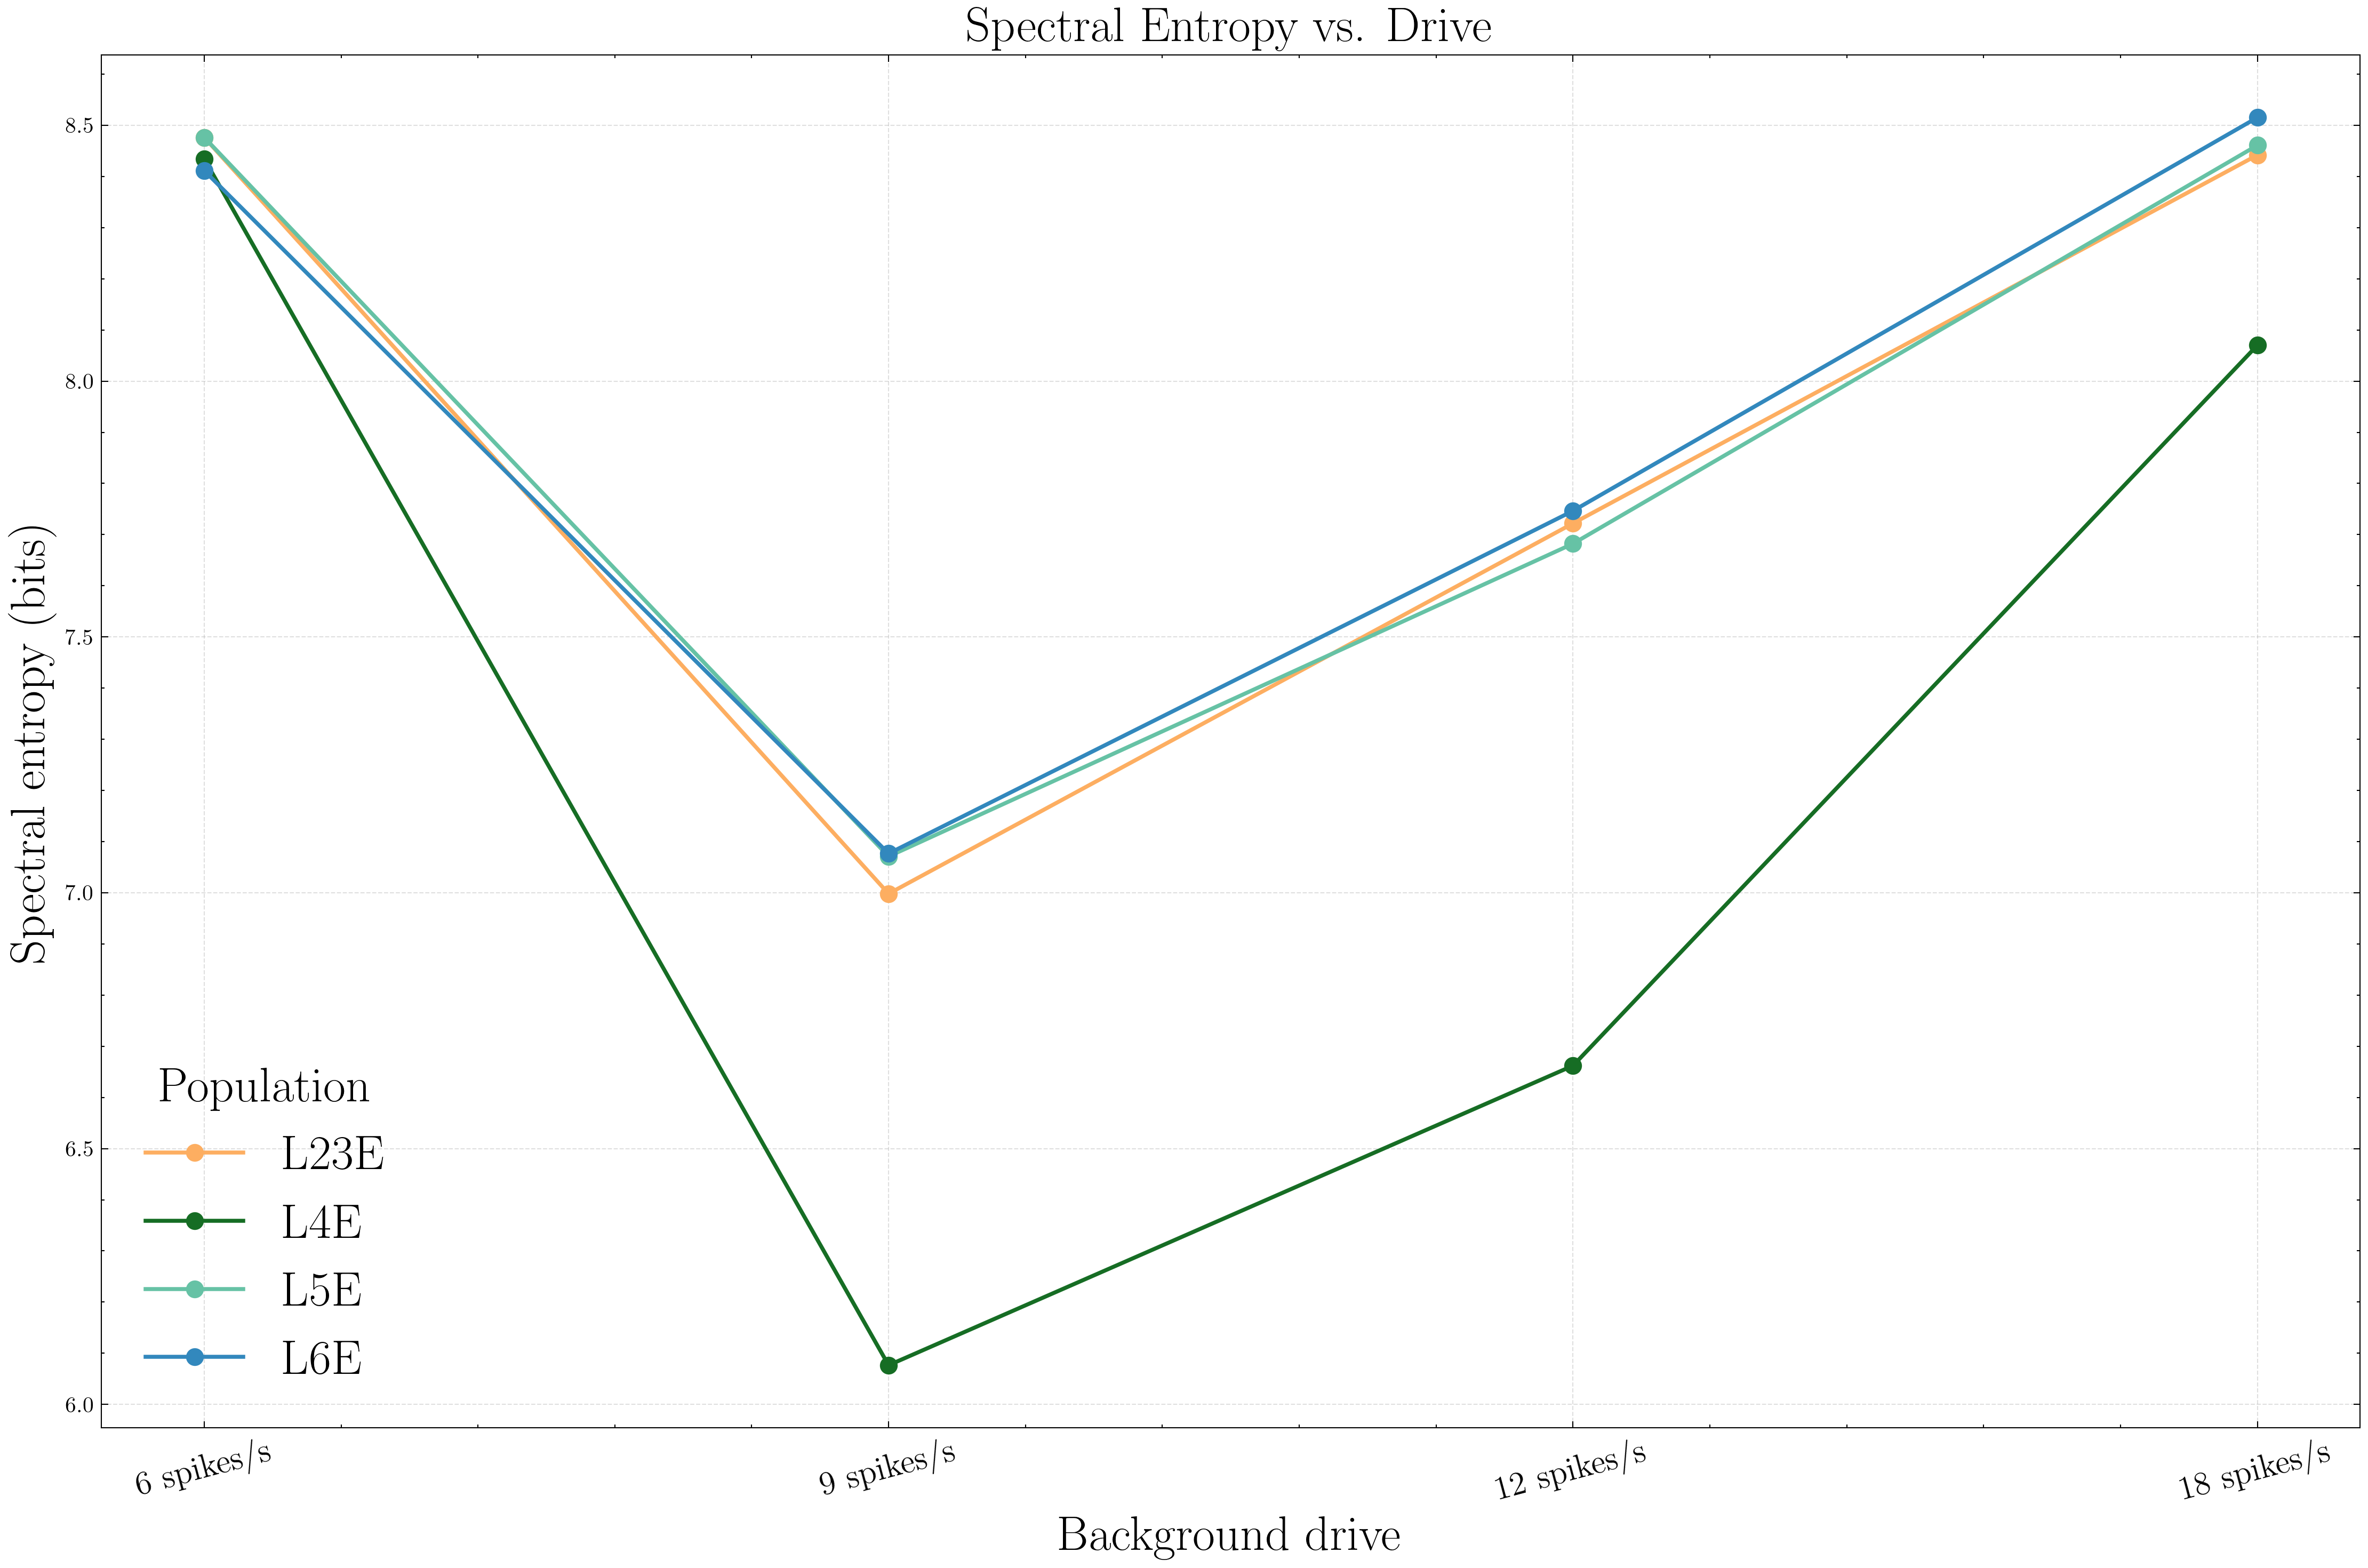

In [5]:
x           = np.arange(n_drives)
markers     = ['o', 'o', 'o', 'o']
colors_pops = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']

fig, axes = plt.subplots(1, 1, figsize=(15, 10), dpi=300)

for pop_idx in range(n_pops):
    axes.plot(x, entropy_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])

    axes.set_title("Spectral Entropy vs. Drive", fontsize=22)
    axes.set_ylabel("Spectral entropy (bits)", fontsize=22)
    axes.set_xticks(x)
    axes.set_xticklabels(labels_rate, rotation=15, fontsize=15)
    axes.set_xlabel("Background drive", fontsize=22)
    axes.legend(title="Population", fontsize=22, title_fontsize=22)
    axes.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Controls: rate-matched shot-noise null + across-seed variability, merged

Two things the observed entropy curve alone can't tell you:

1. Whether a given point is distinguishable from a pure shot-noise (Poisson)
   process at the same rate -- a **rate-matched null** built by generating
   homogeneous Poisson surrogates matched in population size, mean rate, bin
   width, and analysis-window length, then pushed through the identical
   `compute_FFT` -> `compute_spectral_entropy` pipeline used on real data
   (entropy is computed on the same 0-150 Hz band as the observed curve, since
   the full-spectrum version saturates near log2(n_bins) regardless of rate and
   isn't sensitive to real spectral differences).
2. Whether a given point is stable across simulation seeds -- both curves so
   far are a single realisation (`trial_0`). This auto-discovers every
   `trial_*` subfolder under each drive directory and reports the observed
   curve as mean +/- SEM across trials.

The null is estimated once per drive (from the first discovered trial -- it's
the shot-noise floor implied by that drive's rate, not something that should
itself vary trial-to-trial) and plotted as mean +/- SD alongside the observed
mean +/- SEM. The z-score at the end combines both sources of uncertainty.

If you have the finer drive sweep behind Fig. 2L-S, set `DENSE_SWEEP_DIR` below
and this will use it instead of the four coarse points; otherwise it falls back
and warns. This only covers spectral entropy (and reuses the Q-factor/bandwidth
data already computed above) -- the CV-based measure referenced in the draft
text lives elsewhere and would need the same treatment there.

In [6]:
def make_rate_matched_surrogate(mean_rate_hz, n_neurons, n_bins, bin_width_s, rng):
    """
    Homogeneous Poisson surrogate population-rate trace, matched to the real
    signal in mean rate and duration.

    mean_rate_hz : per-neuron mean firing rate (spikes/s) estimated from the
                   real trace over the analysis window
    n_neurons    : population size (N_full for this population)
    n_bins       : number of bins in the analysis window
    bin_width_s  : bin width in seconds (== freq_sample)

    Returns an array of length n_bins in the same units (spikes/s per neuron)
    as pop_activity, so it can be fed straight into compute_FFT.
    """
    lam = mean_rate_hz * n_neurons * bin_width_s      # expected spike count per bin
    counts = rng.poisson(lam, size=n_bins)
    return counts / (n_neurons * bin_width_s)


def surrogate_entropy_null(pop_activity_i, n_pops, N_full, pop_idx_map,
                            freq_sample, n_surrogates=20, seed=0):
    """
    For each population in pop_activity_i, generate n_surrogates rate-matched
    Poisson surrogates, run each through compute_FFT + compute_spectral_entropy,
    and return the mean/SD of the resulting null entropy distribution.
    """
    rng = np.random.default_rng(seed)
    analysis_interval_start = int((addons.analysis_dict["analysis_start"]) / 0.2)
    analysis_interval_end   = int((addons.analysis_dict["analysis_end"]) / 0.2)
    n_bins = analysis_interval_end - analysis_interval_start

    null_entropy = {p: [] for p in range(n_pops)}
    for p in range(n_pops):
        real_trace   = pop_activity_i[p][analysis_interval_start:analysis_interval_end]
        n_pop        = N_full[pop_idx_map[p]]
        mean_rate_hz = real_trace.mean()          # already per-neuron Hz -- do NOT divide by n_pop again

        for _ in range(n_surrogates):
            surrogate_full = np.zeros_like(pop_activity_i[p])
            surrogate_full[analysis_interval_start:analysis_interval_end] =make_rate_matched_surrogate(mean_rate_hz, n_pop, n_bins,freq_sample, rng)
            a, b, _ = compute_FFT({0: surrogate_full}, freq_sample=freq_sample)
            e = compute_spectral_entropy(a, b)
            null_entropy[p].append(e[0])

    null_mean = {p: np.mean(null_entropy[p]) for p in range(n_pops)}
    null_std  = {p: np.std(null_entropy[p])  for p in range(n_pops)}
    return null_mean, null_std

In [7]:
import re

In [8]:
DENSE_SWEEP_DIR = None  # e.g. "data_background_rate_fig2LtoS" -- set if available

def discover_trials(drive_dir):
    return sorted(d for d in os.listdir(drive_dir) if d.startswith("trial_"))

sweep_root = DENSE_SWEEP_DIR if (DENSE_SWEEP_DIR and os.path.isdir(DENSE_SWEEP_DIR)) \
             else "data_background_rate_big"
if DENSE_SWEEP_DIR and not os.path.isdir(DENSE_SWEEP_DIR):
    print(f"WARNING: DENSE_SWEEP_DIR='{DENSE_SWEEP_DIR}' not found -- "
          f"falling back to the 4-point sweep in '{sweep_root}'.")

dirs_sweep = sorted(os.listdir(sweep_root))

MIN_DRIVE = 7.8   # below this the across-trial rate varies by an order of
                  # magnitude at fixed drive, so the spectral estimate is not
                  # comparable across trials

_all = sorted(os.listdir(sweep_root))
drives_all = np.array([float(re.search(r"[\d.]+", d).group()) for d in _all])
keep = drives_all >= MIN_DRIVE
dirs_sweep = [d for d, k in zip(_all, keep) if k]
drives = np.sort(drives_all[keep])
n_sweep = len(dirs_sweep)
print(f"{n_sweep} of {len(_all)} drives retained ({drives.min():.2f} to {drives.max():.2f})")


n_sweep = len(dirs_sweep)

# pop_idx_map: row p in pop_activity -> column in N_full. Default assumes the
# standard Potjans-Diesmann ordering with E populations at 0,2,4,6; edit if your
# net_dict indexes populations differently.
pop_idx_map = {0: 0, 1: 2, 2: 4, 3: 6}
N_full = network_params.net_dict["full_num_neurons"]

entropy_mean  = np.full((n_pops, n_sweep), np.nan)
entropy_sem   = np.full((n_pops, n_sweep), np.nan)
null_mean_arr = np.full((n_pops, n_sweep), np.nan)
null_std_arr  = np.full((n_pops, n_sweep), np.nan)
entropy_all = {p: [None] * n_sweep for p in range(n_pops)}
for i, dname in enumerate(dirs_sweep):
    drive_dir = os.path.join(sweep_root, dname)
    trial_dirs = discover_trials(drive_dir)
    if len(trial_dirs) < 2:
        print(f"WARNING: only {len(trial_dirs)} trial(s) found for '{dname}' -- "
              f"cannot estimate across-seed variability here.")

    entropy_per_trial = {p: [] for p in range(n_pops)}

    for t_idx, tname in enumerate(trial_dirs):
        base = os.path.join(drive_dir, tname, "measurements", "pop_activities")
        pop_activity_t = []
        for j in range(n_pops):
            fpath = os.path.join(base, f"pop_activity_{j*2}.dat")
            pop_activity_t.append(np.loadtxt(fpath))
        pop_activity_t = np.array(pop_activity_t)

        a, b, _ = compute_FFT(pop_activity_t, freq_sample=freq_sample)
        e = compute_spectral_entropy(a, b)   # band-limited to 150 Hz by default
        for p in range(n_pops):
            entropy_per_trial[p].append(e[p])

        # Rate-matched null from the first trial only per drive -- it's the
        # shot-noise floor implied by that drive's rate, not a per-trial quantity.
        if t_idx == 0:
            null_mean, null_std = surrogate_entropy_null(
                pop_activity_t, n_pops, N_full, pop_idx_map,
                freq_sample=freq_sample, n_surrogates=20, seed=i
            )
            for p in range(n_pops):
                null_mean_arr[p, i] = null_mean[p]
                null_std_arr[p, i]  = null_std[p]

    for p in range(n_pops):
        n = len(entropy_per_trial[p])
        entropy_all[p][i] = list(entropy_per_trial[p])
        entropy_mean[p, i] = np.mean(entropy_per_trial[p])
        entropy_sem[p, i]  = np.std(entropy_per_trial[p], ddof=1) / np.sqrt(n) if n > 1 else np.nan

49 of 60 drives retained (7.80 to 20.00)


### Combined view: all populations overlaid, one representative null

Same `entropy_mean`/`entropy_sem`/`null_mean_arr`/`null_std_arr` computed in the
cell above, just replotted as a single panel with all four populations overlaid
(matching the style of the reference figure) instead of four side-by-side
subplots. Only one null curve is drawn -- the four per-population nulls are
all close to flat and close to each other, so plotting all four would just add
clutter without adding information. `NULL_POP_IDX` picks which population's
null to show; change it if you want a different one as the reference.

In [9]:
import matplotlib as mpl
from minimum_entropy import estimate_minimum, annotate, report
import re

   pop   argmin           95% CI   vertex           95% CI  trials
  L23E     8.81     [8.31, 9.58]     8.82     [8.06, 9.37]      10
   L4E     9.58     [8.56, 9.83]     9.14     [8.52, 9.66]      10
   L5E     8.56    [8.56, 10.08]     9.06     [8.75, 9.65]      10
   L6E     9.83    [8.56, 11.36]     9.91    [8.97, 10.94]      10


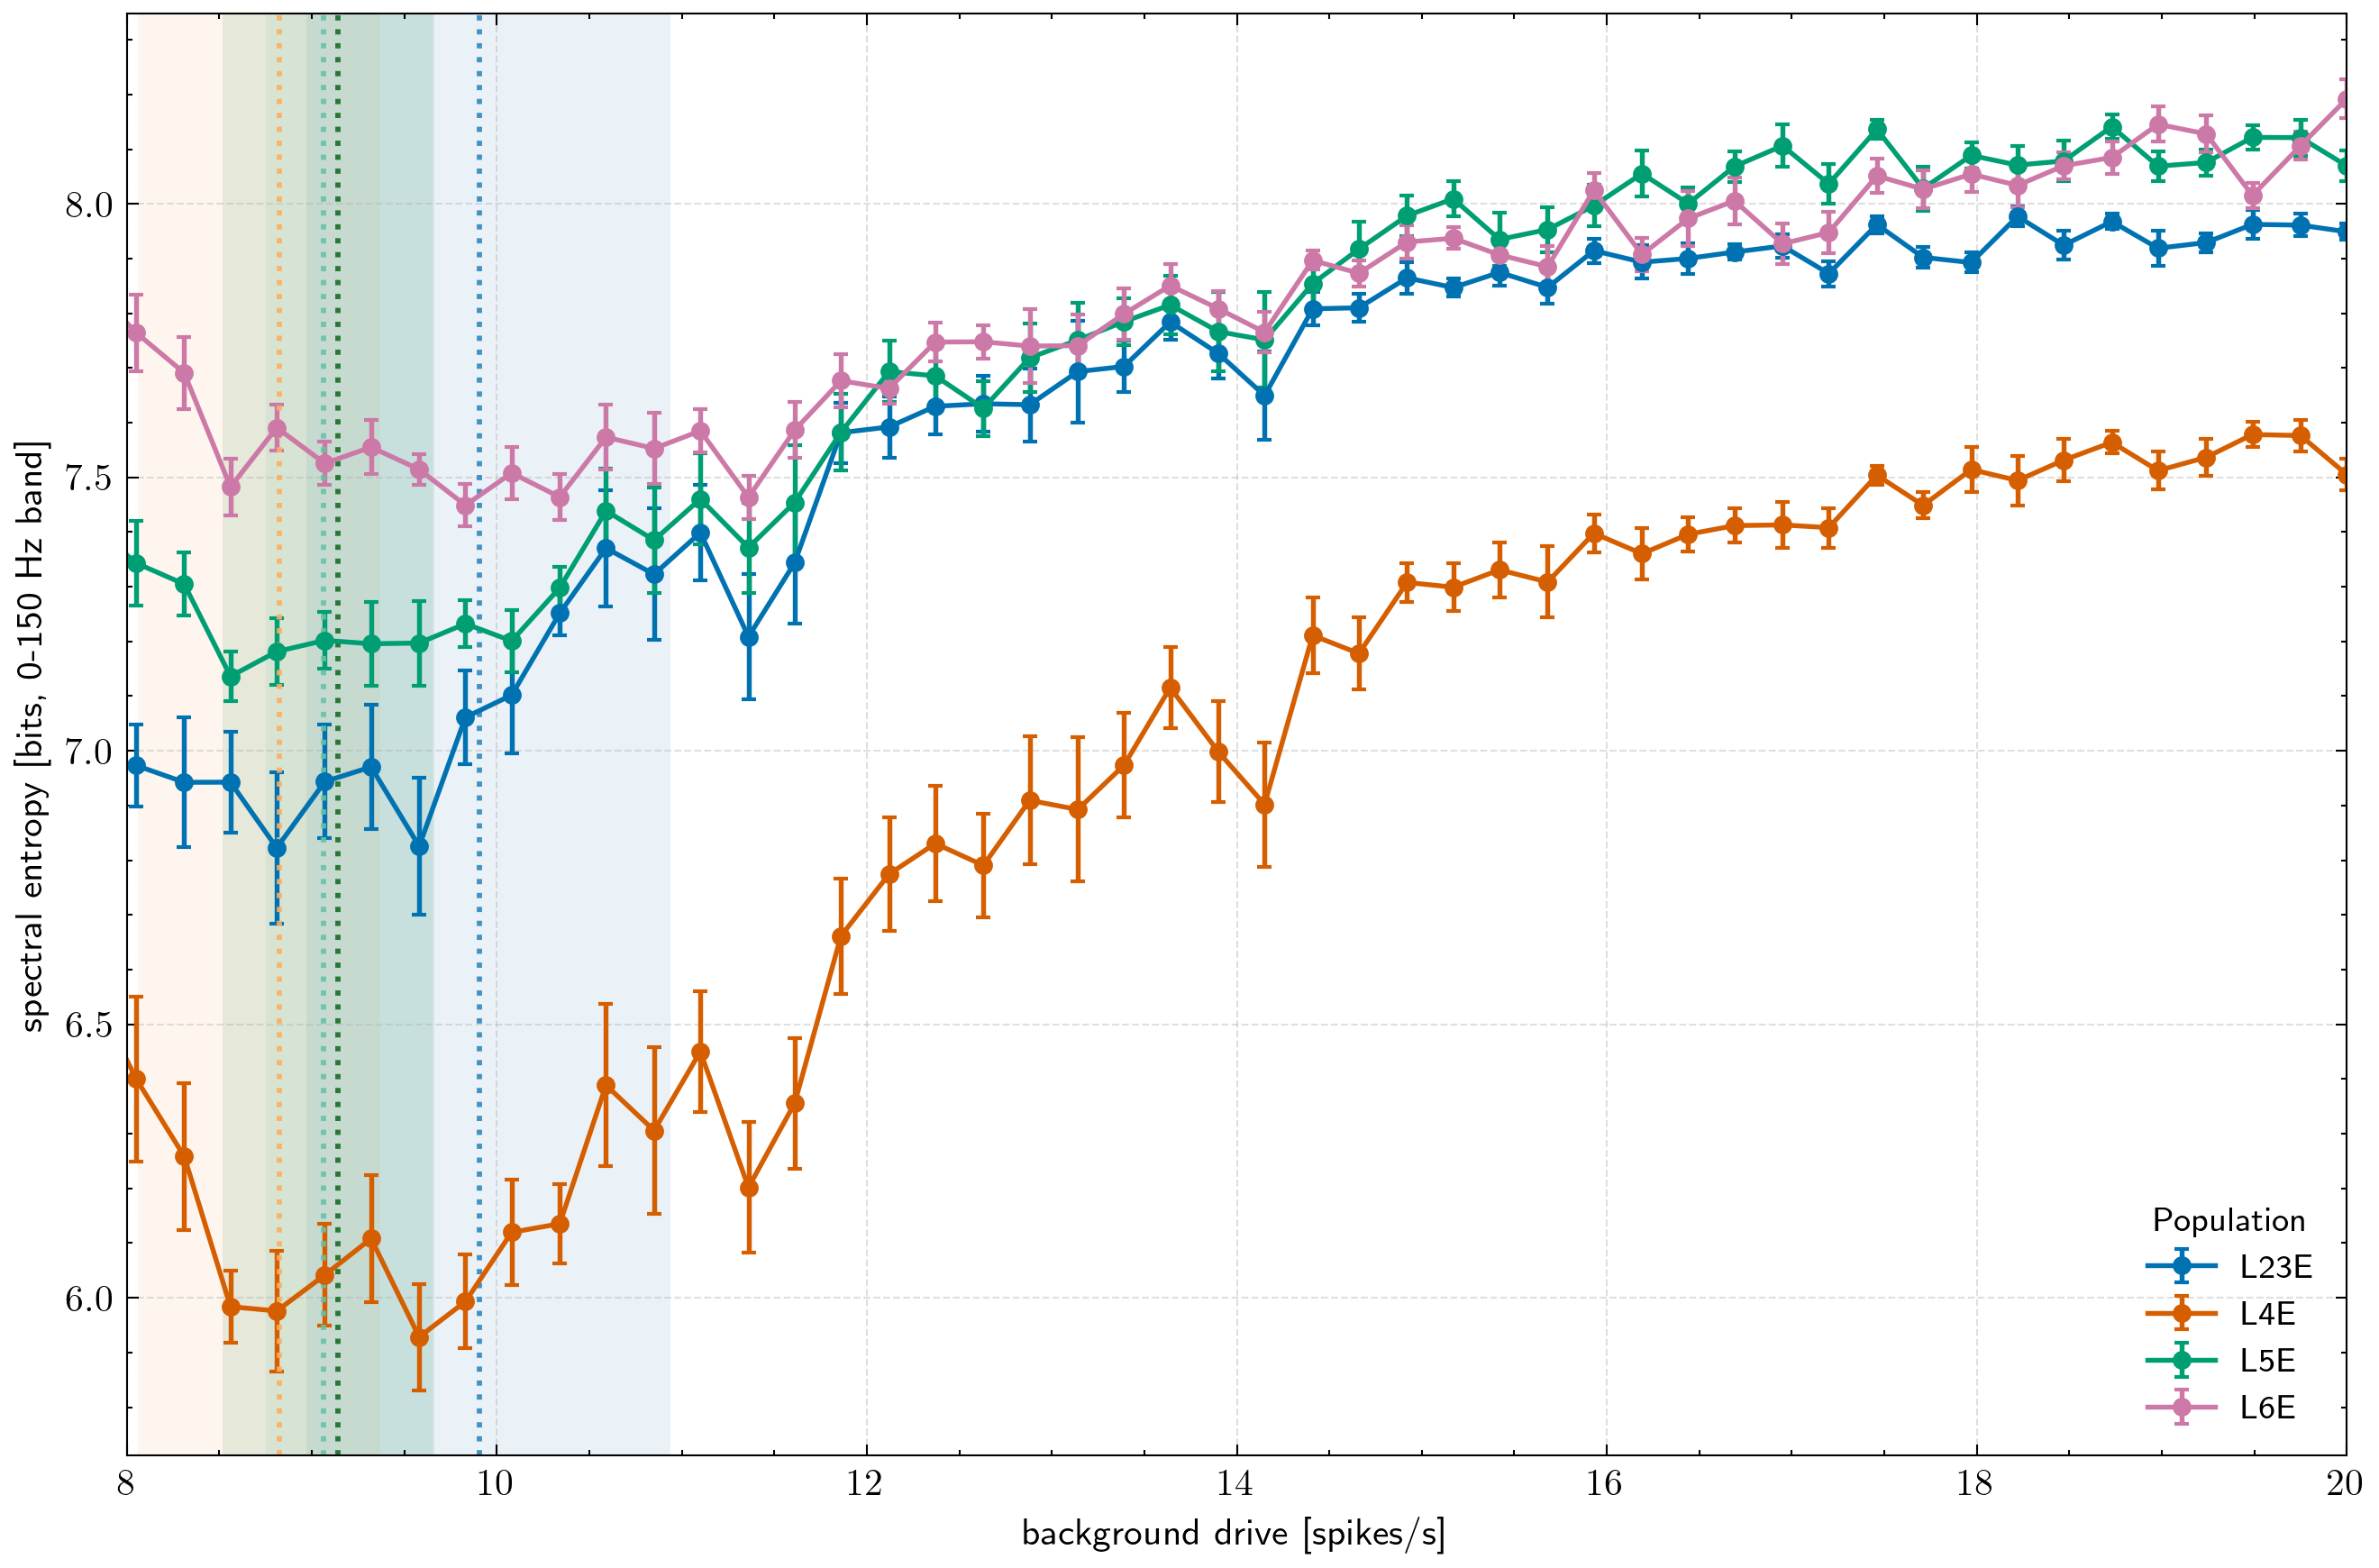

In [15]:
NULL_POP_IDX = 0  # which population's null curve to draw as the single reference (0=L23E)
mpl.rcParams['font.family'] = 'sans-serif'
drives = np.array([float(re.search(r"[\d.]+", d).group()) for d in dirs_sweep])

res = estimate_minimum(entropy_all, drives, pops)   # search_range no longer needed
report(res)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

x_plot =drives 
color_pops = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
for p in range(n_pops):
    ax.errorbar(x_plot, entropy_mean[p], yerr=entropy_sem[p],
                marker="o", markersize=4, linewidth=1.3, capsize=2,
                color=color_pops[p], label=pops[p])
annotate(ax, res, colors_pops)
ax.set_xlim(8, 20)
ax.set_xlabel("background drive [spikes/s]")
ax.set_ylabel("spectral entropy [bits, 0-150 Hz band]")
ax.legend(title="Population", fontsize=9, title_fontsize=9, loc="best")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
report(res)

   pop   argmin           95% CI   vertex           95% CI  trials
  L23E     8.81     [8.31, 9.58]     8.82     [8.06, 9.37]      10
   L4E     9.58     [8.56, 9.83]     9.14     [8.52, 9.66]      10
   L5E     8.56    [8.56, 10.08]     9.06     [8.75, 9.65]      10
   L6E     9.83    [8.56, 11.36]     9.91    [8.97, 10.94]      10


In [12]:
z = np.load('state.npz')
ref = z['rates'][:, :, z['ref_pop']]
cv = ref.std(axis=1) / ref.mean(axis=1)
for d, c, m in zip(z['drives'], cv, ref.mean(axis=1)):
    print(f"{d:6.2f}  mean {m:6.3f} Hz  CV {c:5.2f}")

  5.00  mean  0.297 Hz  CV  1.76
  5.25  mean  0.389 Hz  CV  1.03
  5.51  mean  0.633 Hz  CV  0.67
  5.76  mean  1.034 Hz  CV  0.55
  6.02  mean  0.670 Hz  CV  0.83
  6.27  mean  0.801 Hz  CV  0.77
  6.53  mean  1.080 Hz  CV  0.41
  6.78  mean  1.247 Hz  CV  0.52
  7.03  mean  1.334 Hz  CV  0.45
  7.29  mean  1.279 Hz  CV  0.63
  7.54  mean  1.729 Hz  CV  0.40
  7.80  mean  1.589 Hz  CV  0.29
  8.05  mean  2.018 Hz  CV  0.37
  8.31  mean  2.360 Hz  CV  0.36
  8.56  mean  3.076 Hz  CV  0.11
  8.81  mean  2.883 Hz  CV  0.24
  9.07  mean  3.053 Hz  CV  0.19
  9.32  mean  3.126 Hz  CV  0.26
  9.58  mean  3.180 Hz  CV  0.25
  9.83  mean  3.874 Hz  CV  0.13
 10.08  mean  3.817 Hz  CV  0.20
 10.34  mean  3.798 Hz  CV  0.16
 10.59  mean  4.650 Hz  CV  0.14
 10.85  mean  4.419 Hz  CV  0.11
 11.10  mean  4.512 Hz  CV  0.12
 11.36  mean  4.445 Hz  CV  0.14
 11.61  mean  4.205 Hz  CV  0.18
 11.86  mean  5.124 Hz  CV  0.18
 12.12  mean  5.329 Hz  CV  0.09
 12.37  mean  5.590 Hz  CV  0.11
 12.63  me

In [13]:
for cut in (7.8, 8.5, 9.0):
    print(f"--- min_drive = {cut} ---")
    report(estimate_minimum(entropy_all, drives, pops, min_drive=cut))

--- min_drive = 7.8 ---
   pop   argmin           95% CI   vertex           95% CI  trials
  L23E     8.81     [8.31, 9.58]     8.82     [8.06, 9.37]      10
   L4E     9.58     [8.56, 9.83]     9.14     [8.52, 9.66]      10
   L5E     8.56    [8.56, 10.08]     9.06     [8.75, 9.65]      10
   L6E     9.83    [8.56, 11.36]     9.91    [8.97, 10.94]      10
--- min_drive = 8.5 ---
Dropping 3 drives below 8.5 spikes/s (7.80 to 8.31).
   pop   argmin           95% CI   vertex           95% CI  trials
  L23E     8.81     [8.81, 9.58]     9.01     [7.17, 9.36]      10
   L4E     9.58    [8.81, 10.08]     9.14     [6.99, 9.83]      10
   L5E     9.32    [8.81, 10.08]     7.37     [4.46, 9.72]      10
   L6E     9.83    [9.83, 11.36]     9.91    [9.18, 11.00]      10
--- min_drive = 9.0 ---
Dropping 5 drives below 9.0 spikes/s (7.80 to 8.81).
   pop   argmin           95% CI   vertex           95% CI  trials
  L23E     9.58    [9.32, 10.59]     9.31     [5.77, 9.72]      10
   L4E     9.58   